# Naive Demand Forecasting on Synthetic Supply Chain Data

## Objective
This notebook demonstrates a basic naive and seasonal naive forecasting approach 
using synthetic daily supply chain demand data.

The goal is to:
- Explore demand patterns
- Implement naive forecasting methods
- Evaluate forecast accuracy
- Visualize results

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid")

### Load Data

In [2]:
import sys
from pathlib import Path

# Add src folder to sys.path so we can import data_generation.py
project_root = Path.cwd().parent  # notebook/ → project root
sys.path.append(str(project_root / "src"))

from data_generation import generate_synthetic_demand

# Generate the data
df = generate_synthetic_demand()
df.head()

,date,demand
0,2023-01-01,60.301886
1,2023-01-02,59.085392
2,2023-01-03,57.632150
3,2023-01-04,53.358616
4,2023-01-05,39.189693


### Basic EDA Plot

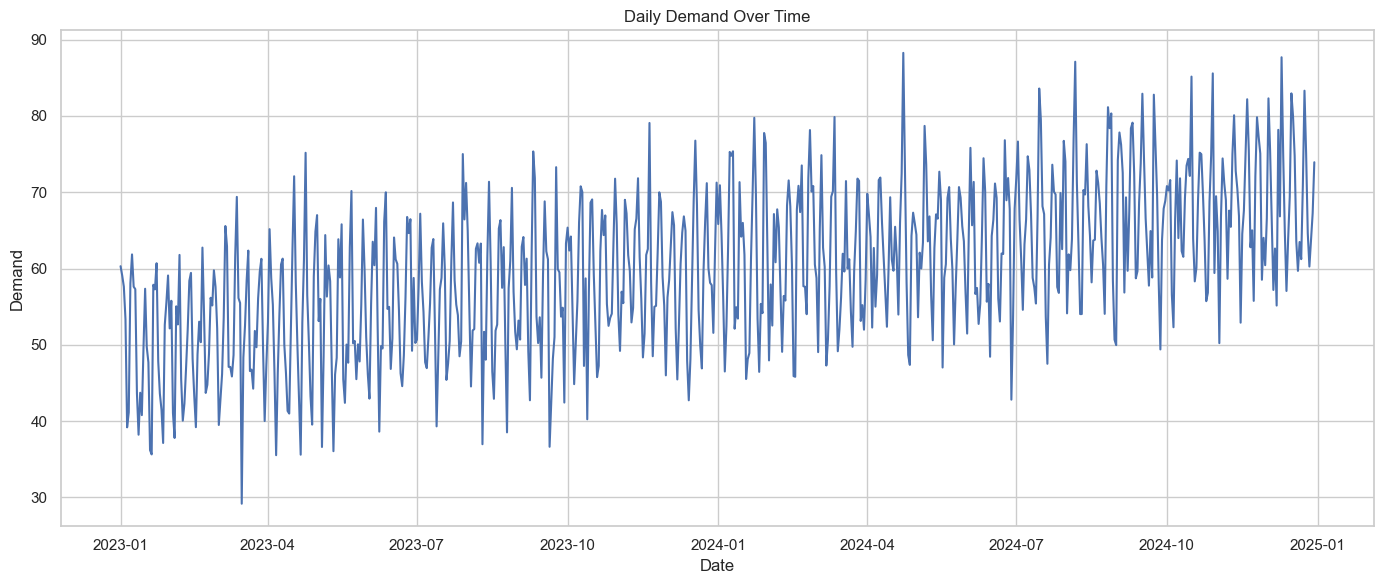

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["demand"])
plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.tight_layout()

plt.show()

### Save EDA Plot

In [10]:
# Save the figure to images folder
images_path = project_root / "images" / "demand_timeseries.png"
plt.savefig(images_path)

<Figure size 640x480 with 0 Axes>

### Seasonal Naive Forecast

In [5]:
# Create a seasonal naive forecast (shifted by 7 days)
df["seasonal_naive"] = df["demand"].shift(7)
df.head(10)

,date,demand,seasonal_naive
0,2023-01-01,60.301886,NaN
1,2023-01-02,59.085392,NaN
2,2023-01-03,57.632150,NaN
3,2023-01-04,53.358616,NaN
4,2023-01-05,39.189693,NaN
5,2023-01-06,41.148175,NaN
6,2023-01-07,58.060673,NaN
7,2023-01-08,61.847532,60.301886
8,2023-01-09,57.621386,59.085392
9,2023-01-10,57.298551,57.632150


### Seasonal Naive Forecast vs Actual Demand Plot

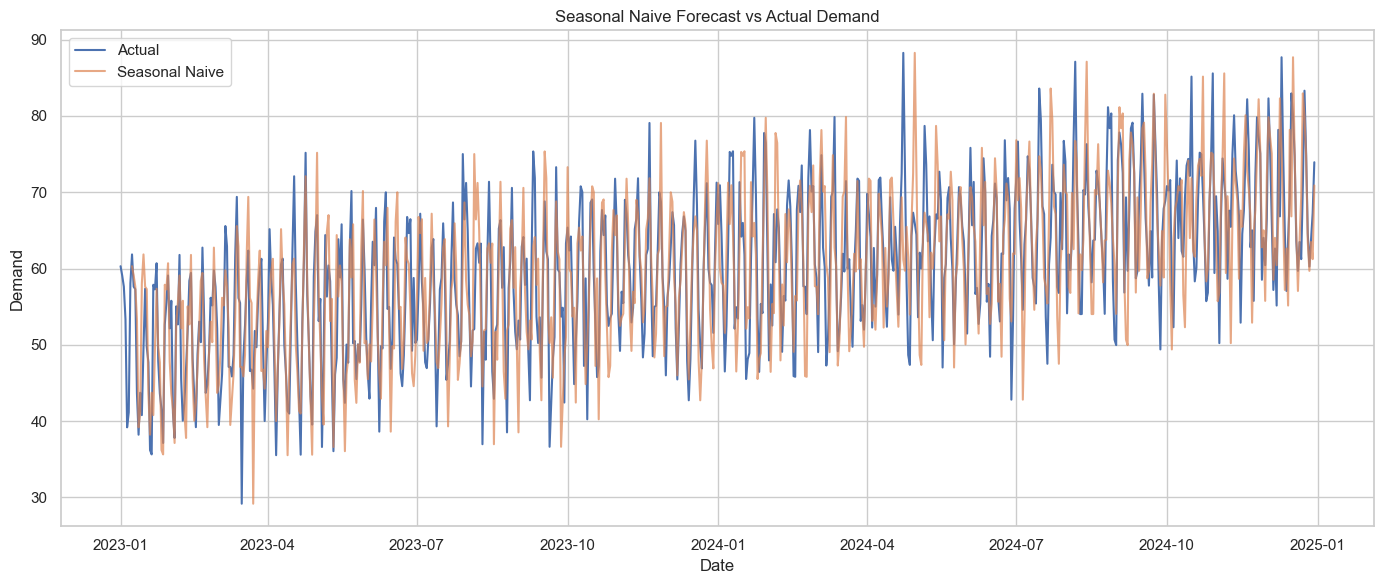

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["demand"], label="Actual")
plt.plot(df["date"], df["seasonal_naive"], label="Seasonal Naive", alpha=0.7)
plt.legend()
plt.title("Seasonal Naive Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.tight_layout()

plt.show()

### Save Seasonal Naive vs Actual Demand Plot

In [11]:
forecast_plot_path = project_root / "images" / "naive_forecast.png"
plt.savefig(forecast_plot_path)

<Figure size 640x480 with 0 Axes>

### Weekly Seasonality Plot

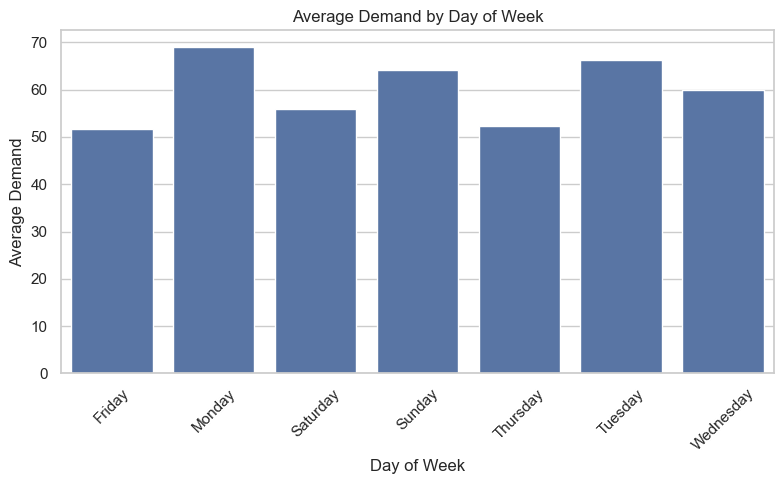

In [12]:
# Add day of week column
df["day_of_week"] = df["date"].dt.day_name()

# Compute average demand per day of week
weekly_avg = df.groupby("day_of_week")["demand"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=weekly_avg.index, y=weekly_avg.values)
plt.xticks(rotation=45)
plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.tight_layout()

plt.show()

### Save Weekly Seasonality Plot

In [13]:
weekly_plot_path = project_root / "images" / "seasonal_pattern.png"
plt.savefig(weekly_plot_path)

<Figure size 640x480 with 0 Axes>

### Evaluate Forecast Accuracy

In [14]:
from sklearn.metrics import mean_absolute_error

# Drop NaNs from shift
df_eval = df.dropna()

mae = mean_absolute_error(df_eval["demand"], df_eval["seasonal_naive"])
print(f"Mean Absolute Error (Seasonal Naive): {mae:.2f}")

Mean Absolute Error (Seasonal Naive): 5.69
